# 📘Домашнє завдання №11 Логістична регресія

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW11

Використайте датасет: **Breast Cancer (sklearn)**.

Ціль: передбачити, чи є пухлина злоякісною:
* 1 — злоякісна (malignant)
* 0 — доброякісна (benign)

Завдання:
1. Розділіть на train/test (80/20) і масштабуйте ознаки (StandardScaler).
2. Натренуйте логістичну регресію, порахуйте для тестового датасету:
    * Confusion Matrix
    * Accuracy
    * Precision
    * Recall
    * F1-score
    * ROC-AUC
3. Побудуйте:
    * ROC-криву
    * Precision-Recall криву
4. Знайдіть коефіцієнти моделі й шанси (odds).
5. Змініть threshold, для кожного порахуйте precision/recall:
    * 0.3
    * 0.5
    * 0.7

In [1]:
# Download data (to cover the case when the data aren't accessible)

# !pip install --upgrade nbformat
# !pip install jinja2

import gc
import shutil
import sqlite3
import pandas as pd
from sklearn.datasets import load_breast_cancer
from pathlib import Path

# Input data
ds_name = "breast_cancer"
db_file_name = "store_hw11.db"
git_project_url = "https://github.com/BogdanPinchuk/DataScience-PBY_HW11.git"
main_file_name = "Bohdan_Pinchuk_DS_HW11.ipynb"

# Solution

# Note: to handle error: "SSL: CERTIFICATE_VERIFY_FAILED" or no connection to the server
try:
    # for testing
    # raise Exception
    ds_sklearn = load_breast_cancer()

    # feature_col_names = [name.replace(' ', '_') for name in ds_sklearn["feature_names"]]
    feature_col_names = ds_sklearn["feature_names"]
    targets = [ds_sklearn["target_names"][::-1][idx] for idx in ds_sklearn["target"]]
    ds_data = pd.DataFrame(ds_sklearn["data"], columns=feature_col_names)
    ds_data["target"] = targets

    del ds_sklearn

    # # Use only one time to initialize/update data (at first time)
    # conn = sqlite3.connect(db_file_name)
    # ds_data.to_sql(ds_name, conn, if_exists="replace", index=False)
    # conn.close()
except Exception:
    file_path = Path(db_file_name)

    if not file_path.exists():
        # upload all files
        current_path = !pwd
        current_path = current_path[0]
        parent_path = !dirname "$current_path"
        parent_path = parent_path[0]
        temp_path = f"{parent_path}/temp"

        # Clone data
        !rm -rf "$temp_path"
        !git clone "$git_project_url" "$temp_path"

        source = Path(temp_path)
        destination = Path(current_path)
        exclude = {main_file_name, ".git", ".idea"}

        for item in source.iterdir():
            if item.name in exclude:
                continue

            target = destination / item.name
            if item.is_dir():
                shutil.copytree(item, target, dirs_exist_ok=True)
            else:
                shutil.copy2(item, target)

        # Clean temp folder
        !rm -rf "$temp_path"

    conn = sqlite3.connect(db_file_name)
    ds_data = pd.read_sql(f"SELECT * FROM {ds_name}", conn)
    conn.close()

# display(ds_data)

# Clean
gc.collect()

406

In [2]:
import numpy as np
import pandas as pd
import jinja2
from pandas.io.formats.style import Styler


class Reporter:
    """
    Class for collecting and printing data in tabular form
    """

    def __init__(self, attribute_col: str = "Attribute", result_col: str = "Result"):
        self._border_sign = "#"
        self._hor_split_sign = "~"
        self._ver_split_sign = "|"
        self._tolerance = 4
        self._max_len_lf: int = 0
        self._max_len_rt: int = 0
        self._data_list: list[tuple[str, str]] = []
        self.attribute_col = attribute_col
        self.result_col = result_col

    @property
    def max_len_lf(self) -> int:
        """Maximum left column width (the 1st column)"""
        return self._max_len_lf

    @property
    def max_len_rt(self) -> int:
        """Maximum right column width (the 2nd column)"""
        return self._max_len_rt

    @property
    def data_list(self) -> list[tuple[str, str]]:
        """The list of data to be printed"""
        return self._data_list

    @property
    def border_sign(self) -> str:
        """Character used for the outside table border"""
        return self._border_sign

    @border_sign.setter
    def border_sign(self, value: str) -> None:
        self._border_sign = value

    @property
    def hor_split_sign(self) -> str:
        """Character used for horizontal splitter in tabular form"""
        return self._hor_split_sign

    @hor_split_sign.setter
    def hor_split_sign(self, value: str) -> None:
        self._hor_split_sign = value

    @property
    def ver_split_sign(self) -> str:
        """Character used for vertical splitter in tabular form"""
        return self._ver_split_sign

    @ver_split_sign.setter
    def ver_split_sign(self, value: str) -> None:
        self._ver_split_sign = value

    @property
    def tolerance(self) -> int:
        """Number of digits after the floating point"""
        return self._tolerance

    @tolerance.setter
    def tolerance(self, value: int) -> None:
        self._tolerance = value

    @property
    def attribute_col(self) -> str:
        """Name of the attribute (the 1st column)"""
        return self._attribute_col

    @attribute_col.setter
    def attribute_col(self, value: str) -> None:
        array_str_key = value.splitlines()
        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))
        self._attribute_col = value

    @property
    def result_col(self) -> str:
        """Name of the result (the 2nd column)"""
        return self._result_col

    @result_col.setter
    def result_col(self, value: str) -> None:
        array_str_value = value.splitlines()
        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))
        self._result_col = value

    def format_value(self, value: float) -> str:
        """
        Format value to string
        :param value: input value
        :return: string of the value
        """
        return f"{value:.{self.tolerance}f}"

    def format_matrix(self, matrix: np.ndarray) -> str:
        """
        Formatting matrix into string
        :param matrix: input matrix
        :return: string of the matrix
        """
        return np.array2string(matrix, precision=self.tolerance)

    def add_item(self, key: str, value: str) -> None:
        """
        Form the report data that consist a multi strings
        :param key: attribute
        :param value: result
        """
        array_str_key = key.splitlines()
        array_str_value = value.splitlines()

        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))

        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))

        self._data_list.append((key, value))

    def _print_line_splitter(self, sign: str = "-") -> None:
        """
        Print line splitter
        """
        print(sign * (self.max_len_lf + self.max_len_rt + 5))

    def _print_multi_string(self, row: tuple[str, str]) -> None:
        """
        Print the multi-string
        :param row: tuple of data
        """
        array_str_key = row[0].splitlines()
        array_str_value = row[1].splitlines()
        num_str = max(len(array_str_key), len(array_str_value))

        for index in range(num_str):
            if index < len(array_str_key):
                left_str = f"{f"{array_str_key[index]}":<{self.max_len_lf}}"
            else:
                left_str = f"{f" ":<{self.max_len_lf}}"

            if index < len(array_str_value):
                right_str = f"{f"{array_str_value[index]:<{self.max_len_rt}}"}"
            else:
                right_str = f"{f" ":<{self.max_len_rt}}"

            print(f" {left_str} {self.ver_split_sign} {right_str}")

    def refresh_table_config(self) -> None:
        """
        Refresh table configuration, like line lengths
        :return:
        """
        self._max_len_lf = 0
        self._max_len_rt = 0

        self.attribute_col = self.attribute_col
        self.result_col = self.result_col

        temp_data_list = self.data_list
        self._data_list = []
        for temp_data in temp_data_list:
            self.add_item(temp_data[0], temp_data[1])

    def print_report(self) -> None:
        """
        Print report data
        """
        self._print_line_splitter(self.border_sign)
        self._print_multi_string((self.attribute_col, self.result_col))
        self._print_line_splitter(self.border_sign)
        for item_data in self.data_list[0:-1]:
            self._print_multi_string(item_data)
            self._print_line_splitter("~")
        self._print_multi_string(self.data_list[-1])
        self._print_line_splitter(self.border_sign)

    def print_refreshed_report(self) -> None:
        """
        Print report data with a refreshing table
        """
        self.refresh_table_config()
        self.print_report()

    def get_pd_report(self, caption: str = "") -> Styler:
        """
        Generate report data using pandas dataframe
        :param caption: caption
        """
        df_data_list = pd.DataFrame(self.data_list, columns=[self.attribute_col, self.result_col])
        pd.set_option('display.max_colwidth', None)
        df_data_list = (df_data_list.style.hide(axis='index')
        .set_properties(**{
            'text-align': 'left',
            'white-space': 'pre-wrap',
            'border': '1px solid lightgrey'
        }).set_table_styles([  # type: ignore
            {"selector": "th", "props": [("text-align", "left")]}
        ])).set_caption(caption)
        return df_data_list

    def print_pd_report(self, caption: str = "") -> None:
        """
        Print report data using pandas dataframe
        """
        df_data_list = self.get_pd_report(caption)
        display(df_data_list)


In [3]:
## Отримання даних

# Solution
breast_cancer = ds_data.copy()
del ds_data

# Print results
display(breast_cancer)

# Clean
gc.collect()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,benign
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,benign
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,benign
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,benign
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,benign
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,benign
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,benign
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,benign


0

## Завдання 0.

Аналіз даних і описова статистика

In [4]:
# Аналіз даних

import numpy as np
import pandas as pd

# Input data
n_columns = breast_cancer.columns.size
n_rows = breast_cancer.index.size

# Solution
columns_df = pd.DataFrame(breast_cancer.columns, columns=["Columns"])
types_df = pd.DataFrame(breast_cancer.dtypes, columns=["Types"])

col_num_type = breast_cancer.select_dtypes(include=np.number).columns
col_cat_type = breast_cancer.select_dtypes(exclude=np.number).columns

empty_val_by_col = breast_cancer.isnull().sum().to_frame(name='Count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
rp.print_pd_report("Параметри таблиці")
display(columns_df.style.set_caption("Назви колонок").hide(axis='index'))
display(types_df.style.set_caption("Типи даних"))


Attribute,Result
Кількість рядків,569
Кількість об’єктів у датасеті,569
Кількість стовпців,31
Кількість числових ознак,30
Кількість категоріальних ознак,1
Пропущені значення,немає


Columns
mean radius
mean texture
mean perimeter
mean area
mean smoothness
mean compactness
mean concavity
mean concave points
mean symmetry
mean fractal dimension


,Types
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [5]:
# Описова статистика

import numpy as np
import pandas as pd

# Input data
balans_level = 0.1
target_value = col_cat_type[0]


# Solution
# Note. I used the "optical" contrast definition
def contrast(val1: np.number, val2: np.number) -> float:
    """
    Contrast between 2 values
    :param val1: first value
    :param val2: second value
    :return: result between 0 and 1
    """
    return abs(val1 - val2) / abs(val1 + val2) if (val1 + val2) != 0 else 0


sorted_class_count = breast_cancer[target_value].value_counts().tolist()
max_contrast = contrast(min(sorted_class_count), max(sorted_class_count))

rp1 = Reporter()
rp1.add_item("Рівень датасету,\nпри якому він буде вважатися збалансованим", f"{balans_level:.2%}")
rp1.add_item("Датасет збалансований", 'так' if max_contrast <= balans_level else 'ні')
rp1.add_item("Максимальна відмінність між класами", f"{max_contrast:.2%}")

data_num_type_df = breast_cancer.select_dtypes(include=np.number)
data_cat_type_df = breast_cancer.select_dtypes(exclude=np.number)

n_outliers = []
for col_name in data_num_type_df.columns:
    col_data = data_num_type_df[col_name].values

    # Calculating outliers
    Q1 = data_num_type_df[col_name].quantile(0.25)
    Q3 = data_num_type_df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = [value for value in col_data if value < lower_limit or value > upper_limit]
    n_outliers.append(len(outliers))

rp2 = Reporter()
for i, col_name in enumerate(data_num_type_df.columns):
    rp2.add_item(f"{col_name}", str(n_outliers[i]))

# Print results
rp1.print_pd_report("Збалансованість датасету")
rp2.print_pd_report("Кількість викидів/outliers")

display(data_cat_type_df.describe().T.style.set_caption("Статистика для категоріальних змінних"))
display(breast_cancer[target_value].value_counts().to_frame().
        style.set_caption("Кількість об’єктів кожного класу"))
display(breast_cancer[target_value].value_counts(normalize=True).to_frame().
        style.set_caption("Співвідношення об’єктів кожного класу"))

display(data_num_type_df.describe().T.style.set_caption("Статистика для числових змінних"))
display(breast_cancer.groupby([target_value]).describe().T.stack().unstack(level=1).
        style.set_caption("Статистика для числових змінних за категорією"))


Attribute,Result
"Рівень датасету, при якому він буде вважатися збалансованим",10.00%
Датасет збалансований,ні
Максимальна відмінність між класами,25.48%


Attribute,Result
mean radius,14
mean texture,7
mean perimeter,13
mean area,25
mean smoothness,6
mean compactness,16
mean concavity,18
mean concave points,10
mean symmetry,15
mean fractal dimension,15


,count,unique,top,freq
target,569,2,malignant,357


,count
target,
malignant,357
benign,212


,proportion
target,
malignant,0.627417
benign,0.372583


,count,mean,std,min,25%,50%,75%,max
mean radius,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
mean texture,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
mean perimeter,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
mean area,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
mean smoothness,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
mean compactness,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
mean concavity,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
mean concave points,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
mean symmetry,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
mean fractal dimension,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


## Завдання 1.

Розділіть на train/test (80/20) і масштабуйте ознаки (StandardScaler).

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Input data
test_ratio = 0.2
rng_seed = 42


# Solution
def name_to_id(name: str) -> int:
    """
    Convert name to idx
    :param name: name
    :return: idx
    """
    match name:
        case ("benign"):
            return 0
        case ("malignant"):
            return 1
        case _:
            raise ValueError("Incorrect input data!")


def id_to_name(idx: int) -> str:
    """
    Convert idx to name
    :param idx: id
    :return: name
    """
    match idx:
        case 0:
            return "benign"
        case 1:
            return "malignant"
        case _:
            raise ValueError("Incorrect input data!")


# pre-processing
breast_cancer_d = breast_cancer.copy()
breast_cancer_d[target_value] = breast_cancer_d.apply(lambda df_row: name_to_id(df_row[target_value]), axis=1)
del breast_cancer

X_data = breast_cancer_d.drop(columns=[target_value])
Y_data = breast_cancer_d[target_value]

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=test_ratio,
                                                    random_state=rng_seed, shuffle=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Print results
rp = Reporter()
for item in data_cat_type_df[target_value].unique():
    rp.add_item(item, str(name_to_id(item)))

# Print results
rp.print_pd_report("Кодування")

display(pd.concat([
    Y_train.value_counts(),
    Y_train.value_counts(normalize=True)
], axis=1).style.set_caption("Вибірка для навчання"))
display(pd.concat([
    Y_test.value_counts(),
    Y_test.value_counts(normalize=True)
], axis=1).style.set_caption("Вибірка для тестування"))

# Clean
gc.collect()

Attribute,Result
benign,0
malignant,1


,count,proportion
target,,
1,286,0.628571
0,169,0.371429


,count,proportion
target,,
1,71,0.622807
0,43,0.377193


134

## Завдання 2.

Натренуйте логістичну регресію, порахуйте для тестового датасету:
* Confusion Matrix
* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, average_precision_score)

# Input data

# Solution
model = LogisticRegression()
model.fit(X_train, Y_train)

# передбачення, чіткі мітки класів
Y_pred = model.predict(X_test)
# імовірність, того що значення належить до позитивного класу "1"
Y_prob = model.predict_proba(X_test)[:, 1]

rp = Reporter()
rp.tolerance = 4

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
rp.add_item("Confusion Matrix", rp.format_matrix(cm))
# Accuracy
accuracy = accuracy_score(Y_test, Y_pred)
rp.add_item("Accuracy\n(Точність)", rp.format_value(accuracy))
# Precision
precision = precision_score(Y_test, Y_pred)
rp.add_item("Precision\n(Влучність)", rp.format_value(precision))
# Recall
recall = recall_score(Y_test, Y_pred)
rp.add_item("Recall\n(Повнота)", rp.format_value(recall))
# F1-score
f1 = f1_score(Y_test, Y_pred)
rp.add_item("F1-score", rp.format_value(f1))
# ROC-AUC
auc = roc_auc_score(Y_test, Y_prob)
rp.add_item("Receiver Operating Characteristic (ROC-AUC)", rp.format_value(auc))
# AP
ap = average_precision_score(Y_test, Y_prob)
rp.add_item("Average Precision (AP)", rp.format_value(ap))

# Print results
rp.print_pd_report("Метрики")

Attribute,Result
Confusion Matrix,[[41 2] [ 1 70]]
Accuracy (Точність),0.9737
Precision (Влучність),0.9722
Recall (Повнота),0.9859
F1-score,0.9790
Receiver Operating Characteristic (ROC-AUC),0.9974
Average Precision (AP),0.9984


## Завдання 3.

Побудуйте:
* ROC-криву
* Precision-Recall криву

In [8]:
from sklearn.metrics import precision_recall_curve, roc_curve

# Input data

# Solution
fpr, tpr, _ = roc_curve(Y_test, Y_prob)
prec, rec, _ = precision_recall_curve(Y_test, Y_prob)


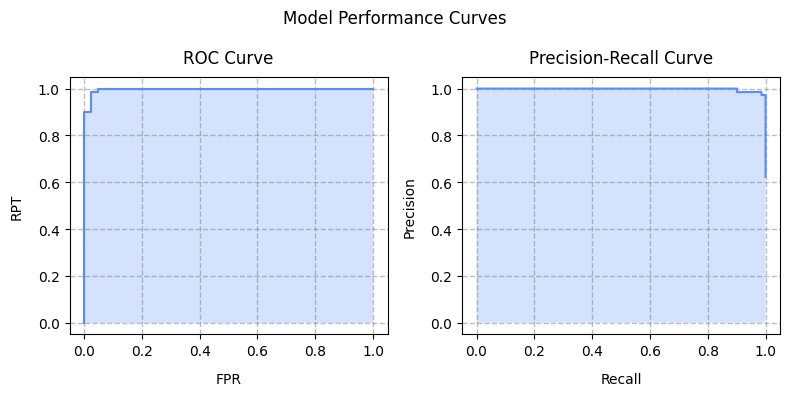

In [9]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes[0]
ax.plot(fpr, tpr)
ax.fill_between(fpr, tpr, alpha=0.25)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("ROC Curve", pad=10, loc='center', color='black')
ax.set_xlabel("FPR", labelpad=10, loc='center', color='black')
ax.set_ylabel("RPT", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.plot(rec, prec)
ax.fill_between(rec, prec, alpha=0.25)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Precision-Recall Curve", pad=10, loc='center', color='black')
ax.set_xlabel("Recall", labelpad=10, loc='center', color='black')
ax.set_ylabel("Precision", labelpad=10, loc='center', color='black')

plt.suptitle(f"Model Performance Curves")

plt.tight_layout()
plt.show()

## Завдання 4.

Знайдіть коефіцієнти моделі й шанси (odds).

In [10]:
import numpy as np
import pandas as pd

# Input data

# Solution
intercept_df = pd.DataFrame({
    "feature": ["intercept beta0"],
    "coefficient": [model.intercept_[0]],
    "odds ratio": [np.exp(model.intercept_[0])],
})
coef_df = pd.DataFrame({
    "feature": X_data.columns,
    "coefficient": model.coef_[0],
    "odds ratio": [np.exp(coef) for coef in model.coef_[0]],
})
total_df = pd.concat([intercept_df, coef_df], ignore_index=True)

# Print results
display(total_df.style.set_caption("Коефіцієнти моделі й шанси"))

,feature,coefficient,odds ratio
0,intercept beta0,0.445585,1.561403
1,mean radius,-0.431904,0.649272
2,mean texture,-0.387326,0.678870
3,mean perimeter,-0.393432,0.674737
4,mean area,-0.465210,0.628003
5,mean smoothness,-0.071667,0.930841
6,mean compactness,0.540164,1.716288
7,mean concavity,-0.801458,0.448674
8,mean concave points,-1.119804,0.326344
9,mean symmetry,0.236119,1.266324


## Завдання 5.

Змініть threshold, для кожного порахуйте precision/recall:
* 0.3
* 0.5
* 0.7

In [38]:
import pandas as pd

# Input data
thresholds = [0.3, 0.5, 0.7]

# Solution
compare_df = pd.DataFrame({})

for i, threshold in enumerate(thresholds):
    y_pred = (Y_prob > threshold).astype(int)

    rp = Reporter()
    rp.tolerance = 4

    # Confusion Matrix
    cm = confusion_matrix(Y_test, y_pred)
    rp.add_item("Confusion Matrix", rp.format_matrix(cm))
    # Accuracy
    accuracy = accuracy_score(Y_test, y_pred)
    rp.add_item("Accuracy\n(Точність)", rp.format_value(accuracy))
    # Precision
    precision = precision_score(Y_test, y_pred)
    rp.add_item("Precision\n(Влучність)", rp.format_value(precision))
    # Recall
    recall = recall_score(Y_test, y_pred)
    rp.add_item("Recall\n(Повнота)", rp.format_value(recall))
    # F1-score
    f1 = f1_score(Y_test, y_pred)
    rp.add_item("F1-score", rp.format_value(f1))

    # Print results
    rp.print_pd_report(f"Метрики для порогу {threshold}")


Attribute,Result
Confusion Matrix,[[41 2] [ 0 71]]
Accuracy (Точність),0.9825
Precision (Влучність),0.9726
Recall (Повнота),1.0000
F1-score,0.9861


Attribute,Result
Confusion Matrix,[[41 2] [ 1 70]]
Accuracy (Точність),0.9737
Precision (Влучність),0.9722
Recall (Повнота),0.9859
F1-score,0.9790


Attribute,Result
Confusion Matrix,[[42 1] [ 4 67]]
Accuracy (Точність),0.9561
Precision (Влучність),0.9853
Recall (Повнота),0.9437
F1-score,0.9640


Із документації для "Confusion Matrix":

Колонка 1 | Колонка 2
--- | ---
true negatives :math:`C_{0,0}` | false positives :math:`C_{0,1}`
false negatives :math:`C_{1,0}` | true positives :math:`C_{1,1}`

Матриця:

№1 | №2
--|--
TN | FP
FN | TP

* TN — фактично/реально 0, передбачено/вгадано 0; (Правильна відмова)
* FP — фактично/реально 0, передбачено/вгадано 1; (Хибна тривога)
* FN — фактично/реально 1, передбачено/вгадано 0; (Пропущений хворий)
* TP — фактично/реально 1, передбачено/вгадано 1; (Влучання)

Пухлина:
* 1 — злоякісна (malignant)
* 0 — доброякісна (benign)

Висновок. Найнебезпечніша помилка (особливо в медицині) — це FN. Поріг в 0.5 допустив 1 критичну помилку, при підвищенні порогу до 0.7 кількість помилок зросла до 4, але при зниженні порогу до 0.3 ми не допустили критичних помилок. Цей результат і відображається за метрикою "Recall". Загалом при збільшенні порогу зростає влучність "Precision", але падає повнота "Recall" (ми пропускаємо хворих).